In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("All imports successful!")

All imports successful!


#All Cols &  Non fraudlament : fraudlament ratio is 96:4 
so even if it gives 96% accuracy its useless if it classifies as non fraudlament every time

In [2]:
df = pd.read_csv('fake_job_postings.csv')

print("Shape:", df.shape)
print("\nFirst look at columns:")
print(df.columns.tolist())
print("\nFraudulent distribution:")
print(df['fraudulent'].value_counts())

Shape: (17880, 18)

First look at columns:
['job_id', 'title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent']

Fraudulent distribution:
fraudulent
0    17014
1      866
Name: count, dtype: int64


In [3]:
print("Null values per column:")
print(df.isnull().sum())

Null values per column:
job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64


Data Cleaning | Null -> ""

In [4]:
text_cols = ['title', 'location','company_profile', 'description', 'requirements','industry','employment_type']

for col in text_cols:
    df[col] = df[col].fillna('')

df['combined_text'] = (
    df['title'] + ' ' +
    df['location'].fillna('') + ' ' +
    df['company_profile'] + ' ' +
    df['description'] + ' ' +
    df['requirements'] + ' ' +
    df['industry'].fillna('') + ' ' +
    df['employment_type'].fillna('')
)

print("Combined text sample:")
print(df['combined_text'][0][:300])
print("\nAny nulls in combined text:", df['combined_text'].isnull().sum())

Combined text sample:
Marketing Intern US, NY, New York We're Food52, and we've created a groundbreaking and award-winning cooking site. We support, connect, and celebrate home cooks, and give them everything they need in one place.We have a top editorial, business, and engineering team. We're focused on using technology

Any nulls in combined text: 0


In [5]:
import re

def clean_text(text):
    text = text.lower()                        
    text = re.sub(r'http\S+', '', text)        
    text = re.sub(r'[^a-zA-Z\s]', '', text)   
    text = re.sub(r'\s+', ' ', text)           
    return text.strip()

df['clean_text'] = df['combined_text'].apply(clean_text)

print("Before cleaning:")
print(df['combined_text'][0][:200])
print("\nAfter cleaning:")
print(df['clean_text'][0][:200])

Before cleaning:
Marketing Intern US, NY, New York We're Food52, and we've created a groundbreaking and award-winning cooking site. We support, connect, and celebrate home cooks, and give them everything they need in 

After cleaning:
marketing intern us ny new york were food and weve created a groundbreaking and awardwinning cooking site we support connect and celebrate home cooks and give them everything they need in one placewe 


In [6]:
from sklearn.model_selection import train_test_split

X = df['clean_text']
y = df['fraudulent']

Xtrain,Xtemp,Ytrain,Ytemp = train_test_split(
    X,y,
    test_size=0.3,
    random_state=42,    
    stratify=y
)

XVal,Xtest,YVal,Ytest = train_test_split(
    Xtemp,Ytemp,
    test_size=0.5,
    random_state=42,
    stratify=Ytemp   
)


print("Train Size:", Xtrain.shape[0])
print("Test Size:", Xtest.shape[0])
print("Val Size:", XVal.shape[0])

print("\nTrain fraud count:", Ytrain.value_counts().to_dict())
print("Val fraud count:", YVal.value_counts().to_dict())
print("Test fraud count:", Ytest.value_counts().to_dict())

Train Size: 12516
Test Size: 2682
Val Size: 2682

Train fraud count: {0: 11910, 1: 606}
Val fraud count: {0: 2552, 1: 130}
Test fraud count: {0: 2552, 1: 130}


In [7]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1,2)
)

Xtrain_tfidf = vectorizer.fit_transform(Xtrain)
XVal_tfidf = vectorizer.transform(XVal)
Xtest_tfidf = vectorizer.transform(Xtest)


print("Train vectorized shape:", Xtrain_tfidf.shape)
print("Val vectorized shape:", XVal_tfidf.shape)
print("Test vectorized shape:", Xtest_tfidf.shape)

Train vectorized shape: (12516, 5000)
Val vectorized shape: (2682, 5000)
Test vectorized shape: (2682, 5000)


In [8]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


smote = SMOTE(random_state=42)
Xtrain_smote,Ytrain_smote =smote.fit_resample(Xtrain_tfidf,Ytrain)


print("Before SMOTE:", Ytrain.value_counts().to_dict())
print("After SMOTE:", {0: sum(Ytrain_smote==0), 1: sum(Ytrain_smote==1)})

Before SMOTE: {0: 11910, 1: 606}
After SMOTE: {0: 11910, 1: 11910}


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


model = RandomForestClassifier(
    n_estimators=200,        
    max_depth=50,            
    min_samples_leaf=2,      
    random_state=42,        
    n_jobs=-1                
)


model.fit(Xtrain_smote, Ytrain_smote)


probs = model.predict_proba(XVal_tfidf)[:, 1]
preds = (probs >= 0.30).astype(int)

report = classification_report(
    YVal,
    preds,
    target_names=['Real', 'Fake']   
)

print("=== Random Forest — Validation Set ===")
print(report)

=== Random Forest — Validation Set ===
              precision    recall  f1-score   support

        Real       0.99      0.99      0.99      2552
        Fake       0.85      0.83      0.84       130

    accuracy                           0.98      2682
   macro avg       0.92      0.91      0.92      2682
weighted avg       0.98      0.98      0.98      2682



In [18]:
# ── Final Evaluation on Held-out Test Set ─────────────────────
# touch this ONCE only — never use test set for tuning decisions
test_probs = model.predict_proba(Xtest_tfidf)[:, 1]
test_preds = (test_probs >= 0.30).astype(int)

print("=== Random Forest — Final Test Set ===")
print(classification_report(
    Ytest,
    test_preds,
    target_names=['Real', 'Fake']
))

=== Random Forest — Final Test Set ===
              precision    recall  f1-score   support

        Real       0.99      0.99      0.99      2552
        Fake       0.82      0.84      0.83       130

    accuracy                           0.98      2682
   macro avg       0.91      0.91      0.91      2682
weighted avg       0.98      0.98      0.98      2682



Real: 500  Fake: 130


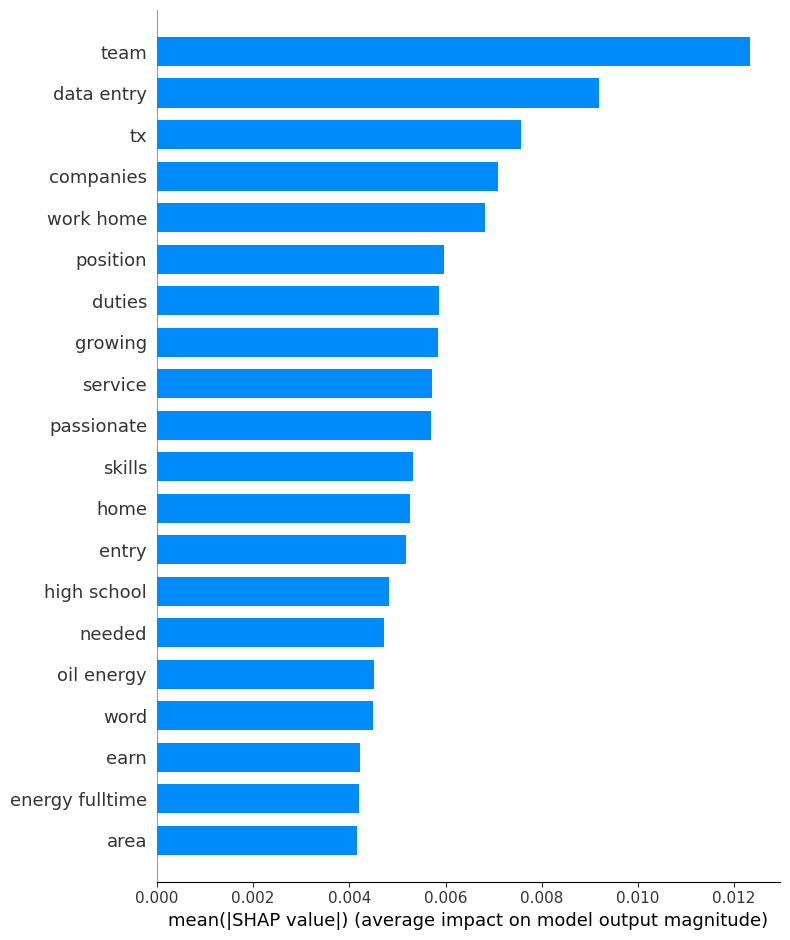

In [23]:
import shap
import numpy as np

# ── Stratified Sample for SHAP ─────────────────────────────────
# using test set — untouched, most honest representation
# 500 real + all 130 fake from test set
real_idx = np.where(Ytest == 0)[0][:500]
fake_idx = np.where(Ytest == 1)[0]

sample_idx = np.concatenate([real_idx, fake_idx])
X_sample = Xtest_tfidf[sample_idx].toarray()
y_sample = np.array(Ytest)[sample_idx]

print(f"Real: {sum(y_sample==0)}  Fake: {sum(y_sample==1)}")

# ── SHAP Explainer ─────────────────────────────────────────────
# TreeExplainer uses model weights internally — not retraining
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

# ── Global Summary Plot ────────────────────────────────────────
# shows top 20 words driving fake job predictions globally
shap.summary_plot(
    shap_values[:, :, 1],       # index 1 = Fake class
    X_sample,
    feature_names=vectorizer.get_feature_names_out(),
    max_display=20,
    plot_type='bar'
)

In [26]:
import pickle

# ── Save Model Artifacts ───────────────────────────────────────
pickle.dump(model, open('model.pkl', 'wb'))
pickle.dump(vectorizer, open('vectorizer.pkl', 'wb'))
pickle.dump({'threshold': 0.30}, open('config.pkl', 'wb'))

print("✅ model.pkl saved")
print("✅ vectorizer.pkl saved")
print("✅ config.pkl saved")

✅ model.pkl saved
✅ vectorizer.pkl saved
✅ config.pkl saved


In [32]:
import pickle
import re

# ── Load Saved Artifacts ───────────────────────────────────────
model = pickle.load(open('model.pkl', 'rb'))
vectorizer = pickle.load(open('vectorizer.pkl', 'rb'))
config = pickle.load(open('config.pkl', 'rb'))
threshold = config['threshold']

# ── Clean Text Function ────────────────────────────────────────
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

# ── Inference Function ─────────────────────────────────────────
def predict_job(job_text):
    cleaned = clean_text(job_text)
    vectorized = vectorizer.transform([cleaned])
    prob = model.predict_proba(vectorized)[0][1]
    verdict = "FAKE" if prob >= threshold else "REAL"
    
    return {
        "verdict"           : verdict,
        "fraud_probability" : f"{round(prob * 100, 2)}%",
        "risk_level"        : "🔴 High"   if prob >= 0.75 else
                              "🟠 Medium" if prob >= 0.55 else
                              "⚠️  Low"   if prob >= 0.30 else
                              "✅ Safe"
    }

# ── Test Job Posting ───────────────────────────────────────────
job_text = """Junior Account Handler – Remote
Company: FinBridge Pvt Ltd

We are looking for motivated individuals to handle daily account 
settlements for our growing client base. No prior finance experience 
required as full training will be provided.

Responsibilities include receiving client deposits, logging 
transactions, and forwarding funds to designated accounts daily.
Salary: Rs 45,000 base plus performance incentives.
Flexible hours, work from home.

Interested candidates send CV and CNIC copy to 
finbridge.hr92@gmail.com. Shortlisted candidates will be 
contacted via WhatsApp within 24 hours."""

result = predict_job(job_text)
print("=== PREDICTION RESULT ===")
for key, value in result.items():
    print(f"{key:<25}: {value}")
    

=== PREDICTION RESULT ===
verdict                  : FAKE
fraud_probability        : 32.42%
risk_level               : ⚠️  Low


Failed Case:

=== PREDICTION RESULT ===
verdict                  : REAL
fraud_probability        : 12.77%
risk_level               : ✅ Safe


Job Opportunity Senior Remote Operations Coordinator APAC Region
Company Global Logistics Asset Management GLAM Solutions
Location Remote Worldwide
Salary 4500 6200 USD per month Performance based bonuses
Asset Flow Management Receive and document high value corporate shipments 
ensuring secondary quality control before redirecting items to regional hubs
Transaction Processing Facilitate the disbursement of operational funds to 
local vendors and contractors using company provided digital portals
Discretion High level of integrity when handling sensitive corporate financial 
data and physical assets
digital wallets online banking cryptocurrency wire transfer
Interview via Telegram or Signal
send CV to hr careers at glamsolutions global net
No applications via third party job boards

── Real World Test Results ────────────────────────────────────
Test 1: Administrative Assistant (subtle fake)
Result: 46.25% FAKE ✅ — model caught it

Test 2: Money Mule Scam (sophisticated corporate language)  
Result: 12.77% REAL ❌ — model fooled by professional tone
Fix: Rule engine catches cryptocurrency + Telegram interview

Test 3: Task/Click Scam (newer pattern)
Result: 24% REAL ❌ — pattern not in training data
Fix: RAG retrieves similar Pakistani task scam examples